In [1]:
print(1)

1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para os gráficos aparecerem no notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Carregando os dados com o encoding correto para este dataset
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# 1. Removendo registros sem ID de cliente
df = df.dropna(subset=['CustomerID'])

# 2. Ajustando o formato de data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Criando a coluna de Faturamento (Quantidade * Preço Unitário)
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

# Exibe as primeiras linhas para conferência
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


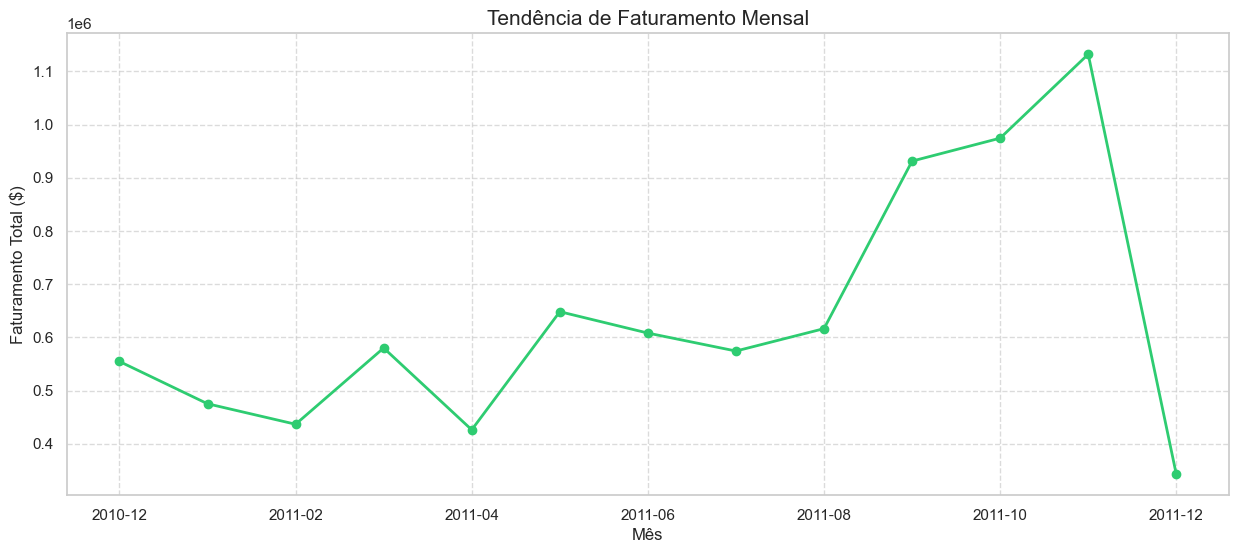

In [3]:
# Criando uma coluna de Mês/Ano
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Agrupando faturamento por mês
faturamento_mensal = df.groupby('MonthYear')['TotalRevenue'].sum()

# Plotando o gráfico
plt.figure(figsize=(15, 6))
faturamento_mensal.plot(kind='line', marker='o', color='#2ecc71', linewidth=2)
plt.title('Tendência de Faturamento Mensal', fontsize=15)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento Total ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\guilh\AppData\Local\Temp\ipykernel_8132\3961649641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_produtos.values, y=top_produtos.index, palette='viridis')


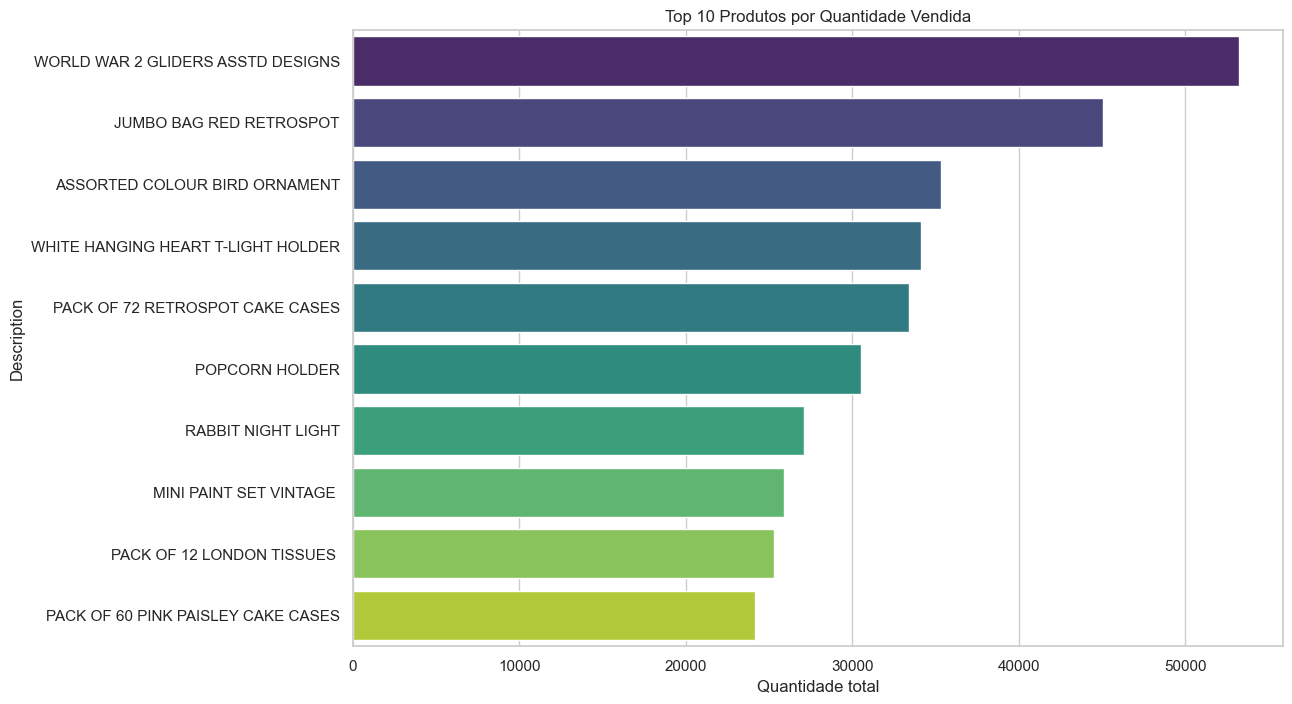

In [4]:
top_produtos = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_produtos.values, y=top_produtos.index, palette='viridis')
plt.title('Top 10 Produtos por Quantidade Vendida')
plt.xlabel('Quantidade total')
plt.show()

In [5]:
from datetime import timedelta

# 1. Definir data de referência para o cálculo de recência
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

# 2. Agrupar por cliente para calcular os 3 pilares:
# Recency: Dias desde a última compra
# Frequency: Quantidade de transações únicas
# Monetary: Soma total gasta
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalRevenue': 'sum'
})

# Renomear colunas para clareza
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalRevenue': 'MonetaryValue'
}, inplace=True)

rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [6]:
# Criando os quartis
r_labels = range(4, 0, -1) # 4 é o melhor (mais recente)
f_labels = range(1, 5)      # 4 é o melhor (mais frequente)
m_labels = range(1, 5)      # 4 é o melhor (gastou mais)

rfm['R'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'], q=4, labels=f_labels)
rfm['M'] = pd.qcut(rfm['MonetaryValue'], q=4, labels=m_labels)

# Criar uma pontuação combinada
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)


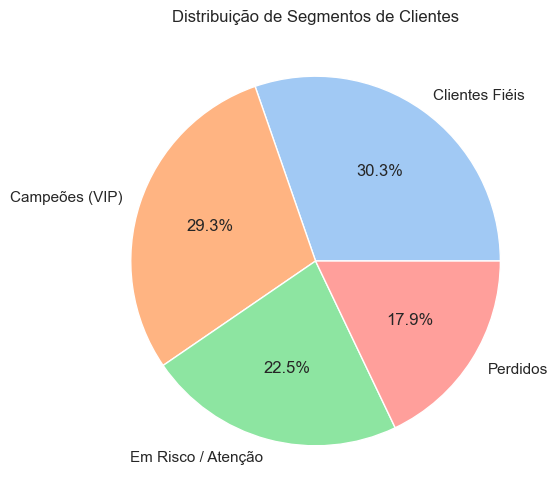

In [12]:
def segmentar_cliente(df):
    if df['RFM_Score'] >= 10:
        return 'Campeões (VIP)'
    elif df['RFM_Score'] >= 7:
        return 'Clientes Fiéis'
    elif df['RFM_Score'] >= 5:
        return 'Em Risco / Atenção'
    else:
        return 'Perdidos'

rfm['Segmento'] = rfm.apply(segmentar_cliente, axis=1)

# Visualizar a distribuição dos segmentos
plt.figure(figsize=(10, 6))
rfm['Segmento'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribuição de Segmentos de Clientes')
plt.ylabel('')
plt.show()

In [8]:
import numpy as np

# 1. Definir o mês da transação e o mês da primeira compra (Cohort) de cada cliente
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

# 2. Calcular o índice da coorte (diferença de meses entre a compra e a primeira vez)
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month
df['CohortIndex'] = years_diff * 12 + months_diff + 1

# 3. Criar a tabela dinâmica (Pivot Table) para a Retenção
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 4. Transformar em porcentagem
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

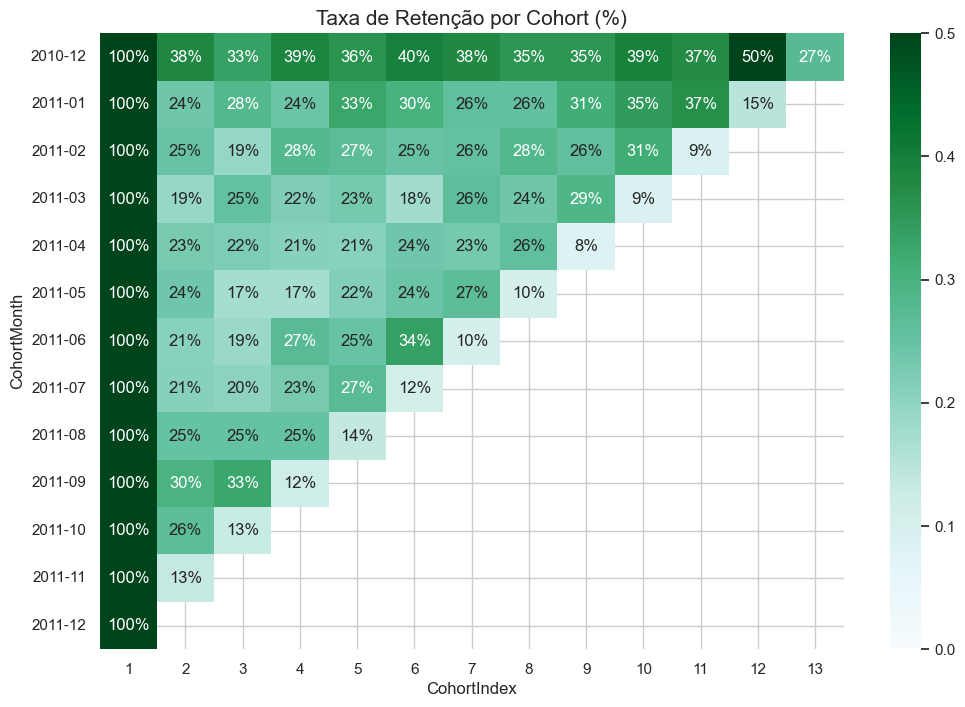

In [9]:
plt.figure(figsize=(12, 8))
plt.title('Taxa de Retenção por Cohort (%)', fontsize=15)
sns.heatmap(data=retention, annot=True, fmt='.0%', vmin=0.0, vmax=0.5, cmap='BuGn')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Agrupar faturamento por mês e resetar o índice
vendas_mensais = df.groupby('MonthYear')['TotalRevenue'].sum().reset_index()

# 2. Criar uma coluna numérica para o tempo (1, 2, 3...)
vendas_mensais['Month_Ordinal'] = range(1, len(vendas_mensais) + 1)

# 3. Definir X (tempo) e y (faturamento)
X = vendas_mensais[['Month_Ordinal']]
y = vendas_mensais['TotalRevenue']

# Dividir entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

R² Score: -1.03
Erro Médio: 341122.45


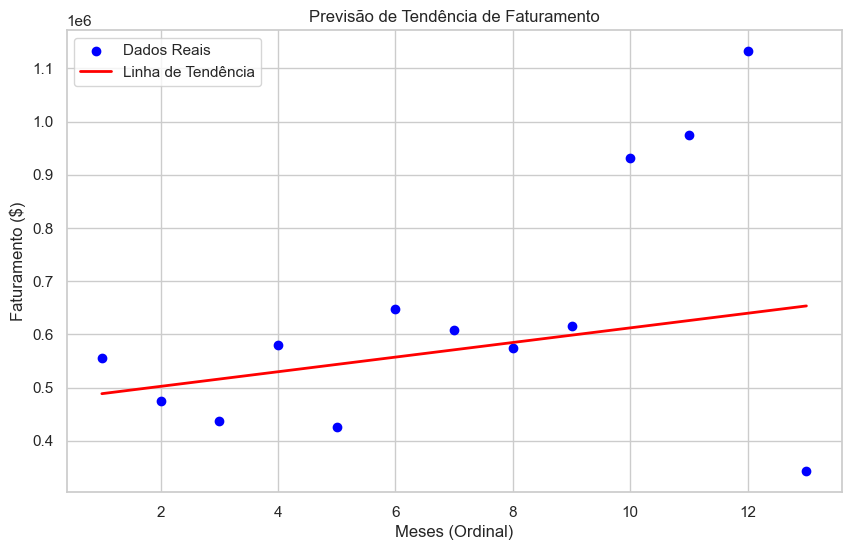

In [11]:
# 1. Instanciar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 2. Fazer previsões
y_pred = modelo.predict(X_test)

# 3. Métricas de performance
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"Erro Médio: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# 4. Visualização da Linha de Tendência
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Dados Reais')
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Linha de Tendência')
plt.title('Previsão de Tendência de Faturamento')
plt.xlabel('Meses (Ordinal)')
plt.ylabel('Faturamento ($)')
plt.legend()
plt.show()